# Cross-Asset Risk Analytics

The objective of this notebook is to analyse the risk and return profile of the selected asset universe.

This notebook uses the cleaned price and return datasets generated by the Market Data Pipeline and computes formal risk metrics such as annualized return, volatility, CAGR, maximum drawdown, Sharpe ratio, Sortino ratio, Value at Risk and Conditional Value at Risk.

The goal is to move from descriptive data exploration to quantitative decision analysis.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../src")

from quant_risk_lab.risk_metrics import (
    load_prices,
    load_returns,
    compute_annualized_return,
    compute_annualized_volatility,
    compute_cagr,
    compute_cumulative_returns,
    compute_drawdowns,
    compute_max_drawdown,
    compute_sharpe_ratio,
    compute_sortino_ratio,
    compute_historical_var,
    compute_historical_cvar,
    build_risk_summary,
)

ModuleNotFoundError: No module named 'config'

## 1. Load Data

We first load the cleaned adjusted close prices and the daily simple returns generated in the previous phase.

In [ ]:
prices = load_prices()

prices.head()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
Date,,,,,,,,
2015-01-02,24.192606,114.080002,46.274326,39.681740,0.482423,169.687836,93.001488,57.145554
2015-01-05,23.511061,115.800003,44.837730,39.316837,0.474275,166.623352,94.462410,55.581959
2015-01-06,23.513273,117.120003,43.675125,38.739761,0.459895,165.053955,96.164352,55.286457
2015-01-07,23.842985,116.430000,43.741779,39.231964,0.458697,167.110672,95.974449,55.846649
2015-01-08,24.759083,115.940002,44.719234,40.386105,0.475952,170.076096,94.703430,56.776207


In [ ]:
returns = load_returns()

returns.head()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
Date,,,,,,,,
2015-01-05,-0.028172,0.015077,-0.031045,-0.009196,-0.016890,-0.018060,0.015709,-0.027362
2015-01-06,0.000094,0.011399,-0.025929,-0.014678,-0.030318,-0.009419,0.018017,-0.005317
2015-01-07,0.014022,-0.005891,0.001526,0.012705,-0.002605,0.012461,-0.001975,0.010133
2015-01-08,0.038422,-0.004209,0.022346,0.029418,0.037618,0.017745,-0.013243,0.016645
2015-01-09,0.001073,0.011385,-0.017387,-0.008405,0.004028,-0.008014,0.010953,-0.001410


In [ ]:
prices.shape, returns.shape

((2888, 8), (2887, 8))

## 2. Risk Summary Table

The following table summarizes the main risk and return metrics for each asset.

In [ ]:
risk_summary = build_risk_summary(prices, returns)

risk_summary

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
AAPL,0.255671,0.238379,0.287205,-0.385159,0.820569,1.133135,0.027173,0.041242
GLD,0.115398,0.107585,0.160462,-0.262109,0.594519,0.799143,0.015514,0.023410
JPM,0.208304,0.186859,0.270359,-0.436265,0.696499,0.947386,0.025227,0.038525
MSFT,0.231761,0.214177,0.272445,-0.371485,0.777260,1.066588,0.026612,0.038881
NVDA,0.639539,0.685477,0.482933,-0.663351,1.282868,1.900186,0.044280,0.065020
SPY,0.144265,0.136845,0.176542,-0.337173,0.703885,0.862963,0.016650,0.026828
TLT,0.005633,-0.005353,0.148476,-0.483511,-0.096760,-0.146026,0.014842,0.020298
XOM,0.114077,0.078933,0.275201,-0.613425,0.341847,0.480064,0.025966,0.039652


In [ ]:
risk_summary_percent = risk_summary.copy()

percentage_columns = [
    "Annualized Return",
    "CAGR",
    "Annualized Volatility",
    "Maximum Drawdown",
    "Historical VaR 95%",
    "Historical CVaR 95%",
]

risk_summary_percent[percentage_columns] = risk_summary_percent[percentage_columns] * 100

risk_summary_percent

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
AAPL,25.567136,23.837927,28.720483,-38.515924,0.820569,1.133135,2.717271,4.124151
GLD,11.539779,10.758508,16.046221,-26.210926,0.594519,0.799143,1.551359,2.340950
JPM,20.830450,18.685875,27.035869,-43.626483,0.696499,0.947386,2.522676,3.852453
MSFT,23.176099,21.417750,27.244536,-37.148486,0.777260,1.066588,2.661230,3.888089
NVDA,63.953933,68.547721,48.293315,-66.335101,1.282868,1.900186,4.427988,6.501973
SPY,14.426513,13.684513,17.654178,-33.717256,0.703885,0.862963,1.665008,2.682825
TLT,0.563348,-0.535318,14.847579,-48.351131,-0.096760,-0.146026,1.484177,2.029837
XOM,11.407655,7.893276,27.520076,-61.342491,0.341847,0.480064,2.596590,3.965250


## 3. Annualized Return

Annualized return estimates the average yearly return based on daily returns. It is computed as the mean daily return multiplied by the number of trading days in a year.

This metric gives a first approximation of return, but it does not fully capture compounding. For that reason, CAGR is also analysed.

In [ ]:
annualized_return = compute_annualized_return(returns).sort_values(ascending=False)

annualized_return

NVDA    0.639539
AAPL    0.255671
MSFT    0.231761
JPM     0.208304
SPY     0.144265
GLD     0.115398
XOM     0.114077
TLT     0.005633
dtype: float64

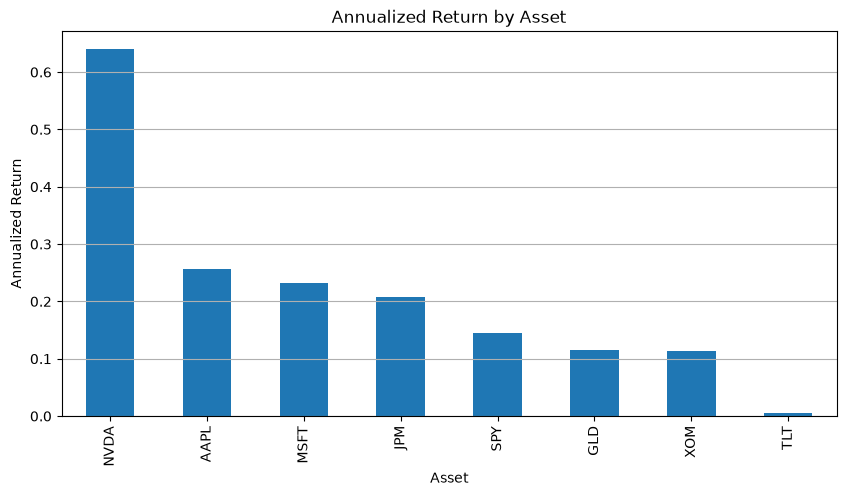

In [ ]:
annualized_return.plot(kind="bar", figsize=(10, 5))
plt.title("Annualized Return by Asset")
plt.ylabel("Annualized Return")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 4. CAGR

CAGR measures the compound annual growth rate of each asset over the full period. Unlike the arithmetic annualized return, CAGR reflects the actual compounded growth from the initial price to the final price.

In [ ]:
cagr = compute_cagr(prices).sort_values(ascending=False)

cagr

NVDA    0.685477
AAPL    0.238379
MSFT    0.214177
JPM     0.186859
SPY     0.136845
GLD     0.107585
XOM     0.078933
TLT    -0.005353
dtype: float64

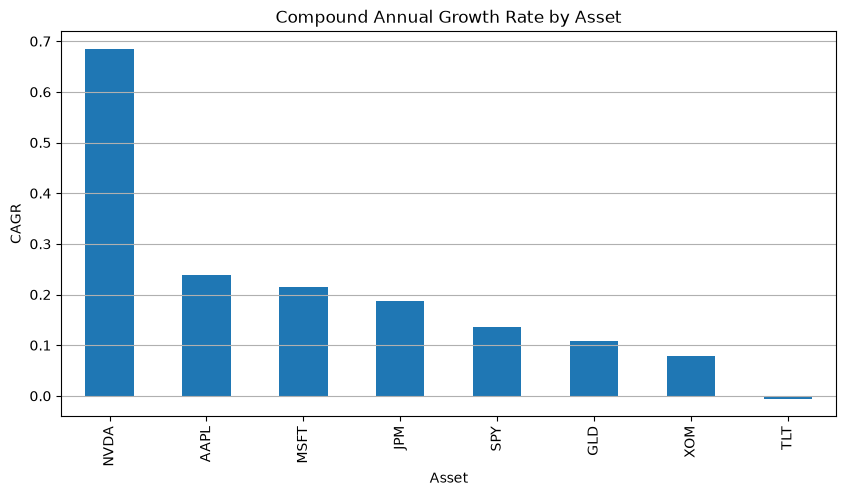

In [ ]:
cagr.plot(kind="bar", figsize=(10, 5))
plt.title("Compound Annual Growth Rate by Asset")
plt.ylabel("CAGR")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 5. Annualized Volatility

Volatility measures the dispersion of daily returns. In this notebook, daily volatility is annualized by multiplying it by the square root of 252.

Higher volatility means larger fluctuations and greater uncertainty.

In [ ]:
annualized_volatility = compute_annualized_volatility(returns).sort_values(ascending=False)

annualized_volatility

NVDA    0.482933
AAPL    0.287205
XOM     0.275201
MSFT    0.272445
JPM     0.270359
SPY     0.176542
GLD     0.160462
TLT     0.148476
dtype: float64

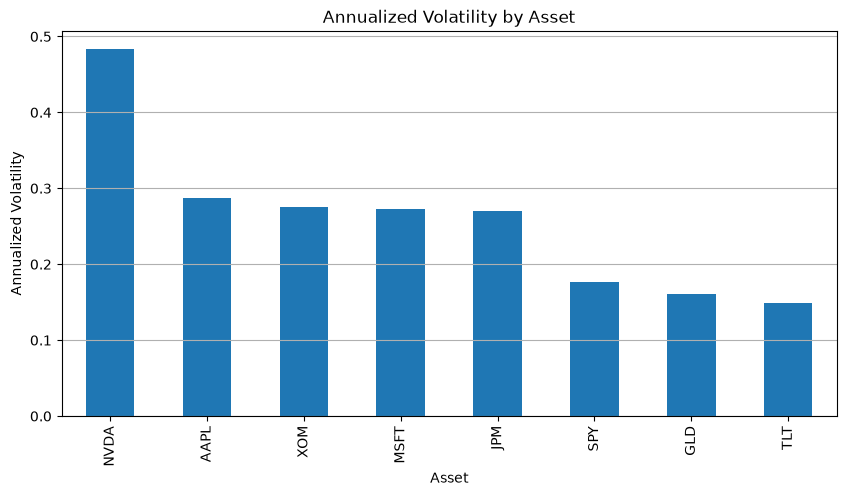

In [ ]:
annualized_volatility.plot(kind="bar", figsize=(10, 5))
plt.title("Annualized Volatility by Asset")
plt.ylabel("Annualized Volatility")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 6. Cumulative Returns

Cumulative returns show the growth of one monetary unit invested in each asset at the beginning of the period.

In [ ]:
cumulative_returns = compute_cumulative_returns(returns)

cumulative_returns.head()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
Date,,,,,,,,
2015-01-05,0.971828,1.015077,0.968955,0.990804,0.983110,0.981940,1.015709,0.972638
2015-01-06,0.971920,1.026648,0.943831,0.976262,0.953303,0.972692,1.034009,0.967467
2015-01-07,0.985548,1.020600,0.945271,0.988665,0.950820,0.984812,1.031967,0.977270
2015-01-08,1.023415,1.016304,0.966394,1.017750,0.986587,1.002288,1.018300,0.993537
2015-01-09,1.024513,1.027875,0.949591,1.009196,0.990561,0.994256,1.029454,0.992136


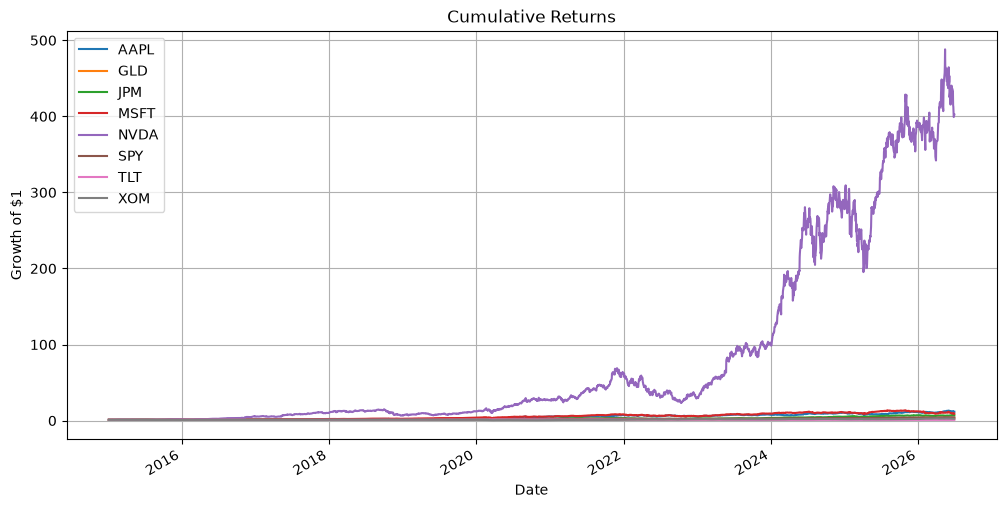

In [ ]:
cumulative_returns.plot(figsize=(12, 6))
plt.title("Cumulative Returns")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.grid(True)
plt.show()

## 7. Drawdown Analysis

Drawdown measures the percentage decline from a previous peak. It is important because it shows the losses an investor would have experienced during the period.

In [ ]:
drawdowns = compute_drawdowns(returns)

drawdowns.head()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
Date,,,,,,,,
2015-01-05,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2015-01-06,0.0,0.000000,-0.025929,-0.014678,-0.030318,-0.009419,0.000000,-0.005317
2015-01-07,0.0,-0.005891,-0.024443,-0.002159,-0.032845,0.000000,-0.001975,0.000000
2015-01-08,0.0,-0.010075,-0.002643,0.000000,0.000000,0.000000,-0.015192,0.000000
2015-01-09,0.0,0.000000,-0.019984,-0.008405,0.000000,-0.008014,-0.004405,-0.001410


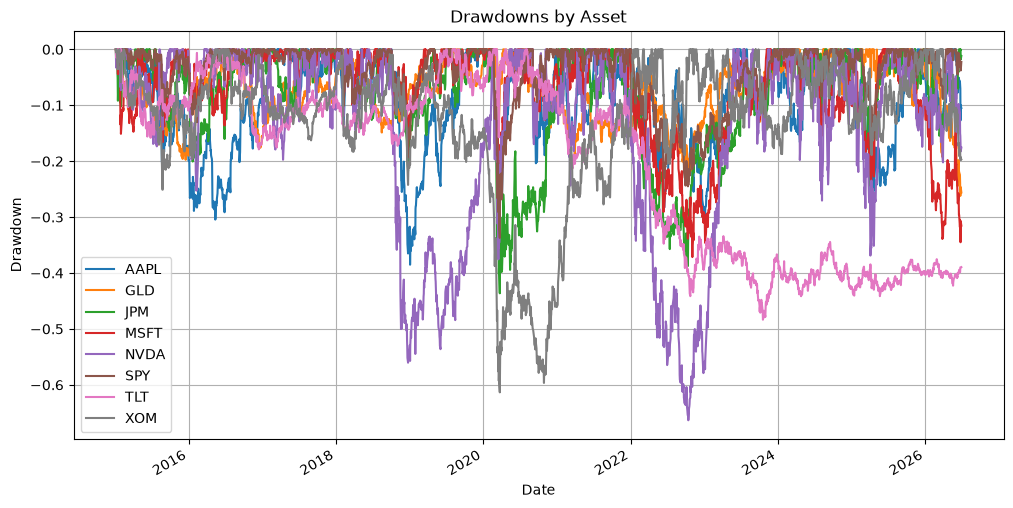

In [ ]:
drawdowns.plot(figsize=(12, 6))
plt.title("Drawdowns by Asset")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.grid(True)
plt.show()

## 8. Maximum Drawdown

Maximum Drawdown is the worst peak-to-trough loss during the analysed period.

In [ ]:
max_drawdown = compute_max_drawdown(returns).sort_values()

max_drawdown

NVDA   -0.663351
XOM    -0.613425
TLT    -0.483511
JPM    -0.436265
AAPL   -0.385159
MSFT   -0.371485
SPY    -0.337173
GLD    -0.262109
dtype: float64

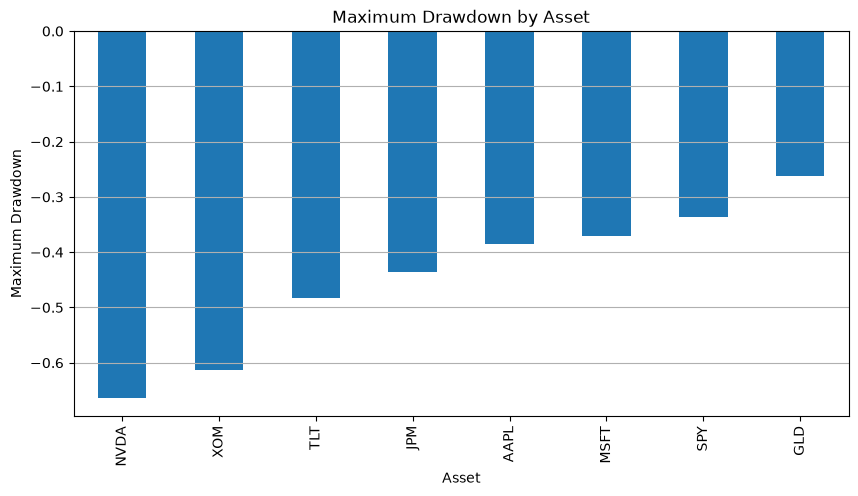

In [ ]:
max_drawdown.plot(kind="bar", figsize=(10, 5))
plt.title("Maximum Drawdown by Asset")
plt.ylabel("Maximum Drawdown")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 9. Sharpe Ratio

The Sharpe Ratio measures excess return per unit of total risk.

It is computed as:

Sharpe Ratio = (Annualized Return - Risk-Free Rate) / Annualized Volatility

A higher Sharpe Ratio indicates better return adjusted for volatility.

In [ ]:
sharpe_ratio = compute_sharpe_ratio(returns).sort_values(ascending=False)

sharpe_ratio

NVDA    1.282868
AAPL    0.820569
MSFT    0.777260
SPY     0.703885
JPM     0.696499
GLD     0.594519
XOM     0.341847
TLT    -0.096760
dtype: float64

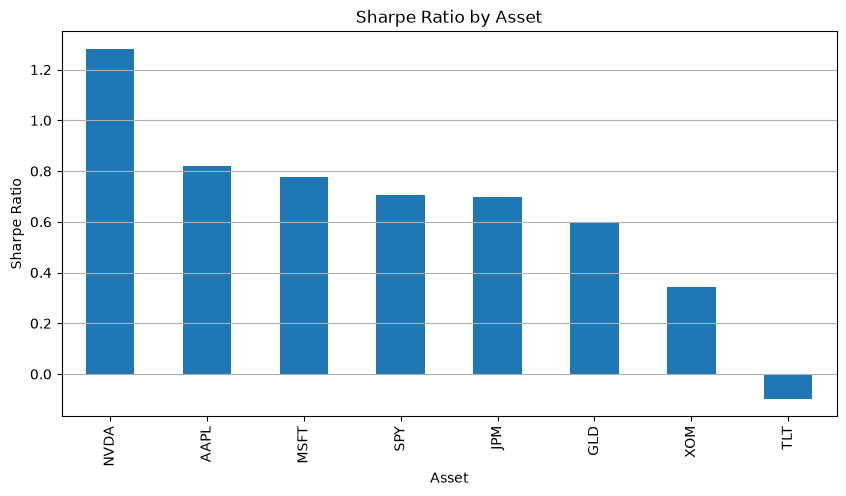

In [ ]:
sharpe_ratio.plot(kind="bar", figsize=(10, 5))
plt.title("Sharpe Ratio by Asset")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 10. Sortino Ratio

The Sortino Ratio is similar to the Sharpe Ratio, but it only penalizes downside volatility.

This is useful because investors are usually more concerned about negative deviations than positive ones.

In [ ]:
sortino_ratio = compute_sortino_ratio(returns).sort_values(ascending=False)

sortino_ratio

NVDA    1.900186
AAPL    1.133135
MSFT    1.066588
JPM     0.947386
SPY     0.862963
GLD     0.799143
XOM     0.480064
TLT    -0.146026
dtype: float64

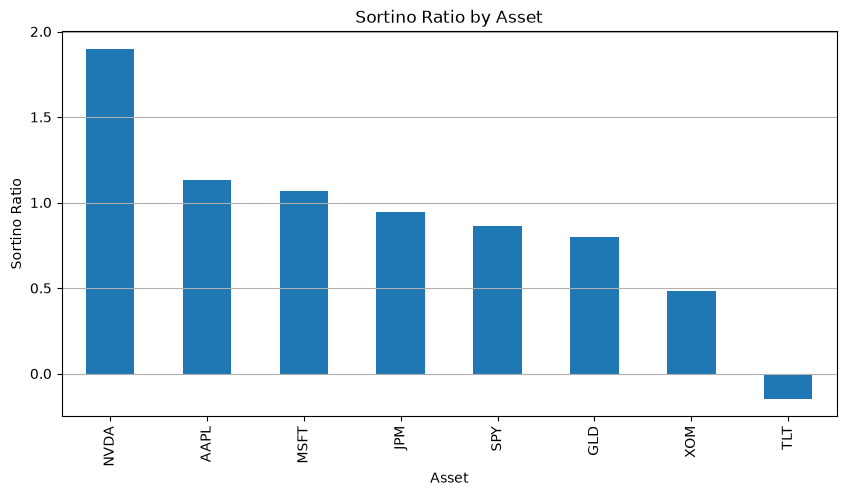

In [ ]:
sortino_ratio.plot(kind="bar", figsize=(10, 5))
plt.title("Sortino Ratio by Asset")
plt.ylabel("Sortino Ratio")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 11. Historical Value at Risk

Historical VaR estimates the loss threshold at a given confidence level.

A 95% daily VaR answers the question:

"What daily loss should not be exceeded in 95% of historical observations?"

In [ ]:
historical_var = compute_historical_var(returns, confidence_level=0.95).sort_values(ascending=False)

historical_var

NVDA    0.044280
AAPL    0.027173
MSFT    0.026612
XOM     0.025966
JPM     0.025227
SPY     0.016650
GLD     0.015514
TLT     0.014842
Name: 0.050000000000000044, dtype: float64

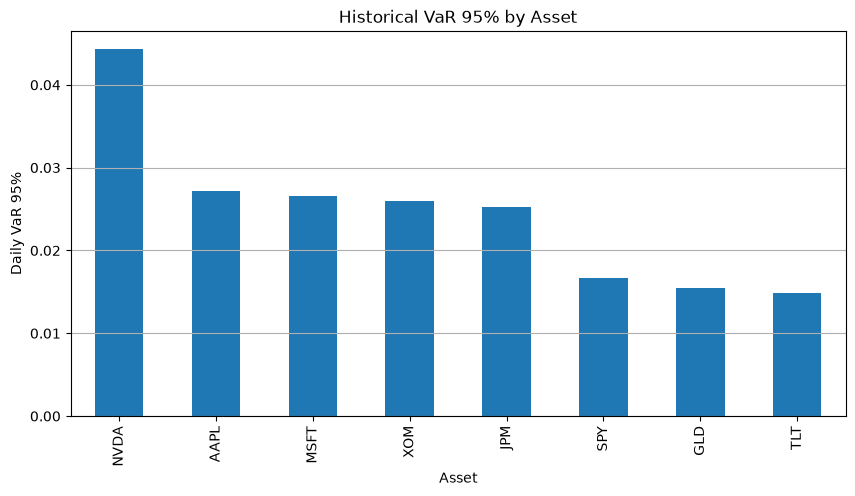

In [ ]:
historical_var.plot(kind="bar", figsize=(10, 5))
plt.title("Historical VaR 95% by Asset")
plt.ylabel("Daily VaR 95%")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 12. Historical Conditional Value at Risk

CVaR measures the average loss beyond the VaR threshold.

While VaR tells us where the extreme-loss region starts, CVaR tells us how severe losses are inside that region.

In [ ]:
historical_cvar = compute_historical_cvar(returns, confidence_level=0.95).sort_values(ascending=False)

historical_cvar

NVDA    0.065020
AAPL    0.041242
XOM     0.039652
MSFT    0.038881
JPM     0.038525
SPY     0.026828
GLD     0.023410
TLT     0.020298
dtype: float64

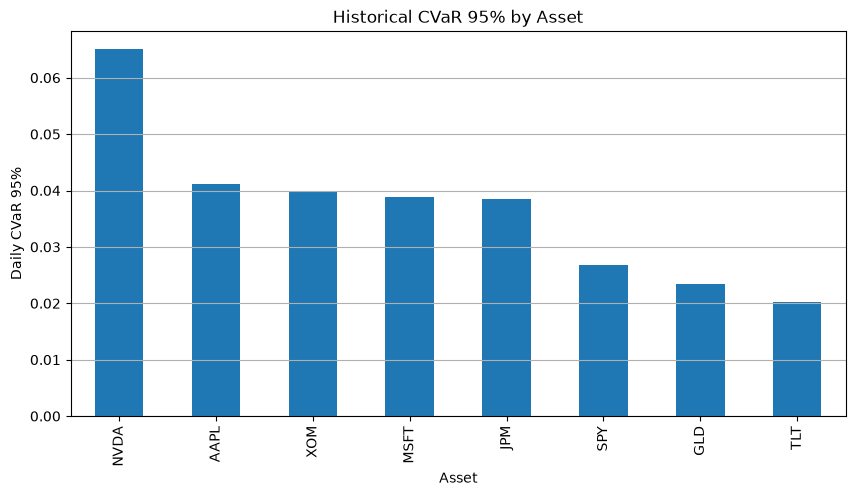

In [ ]:
historical_cvar.plot(kind="bar", figsize=(10, 5))
plt.title("Historical CVaR 95% by Asset")
plt.ylabel("Daily CVaR 95%")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 13. Risk and Return Rankings

The following rankings help compare assets across return, risk and risk-adjusted performance.

In [ ]:
risk_summary.sort_values("CAGR", ascending=False)

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
NVDA,0.639539,0.685477,0.482933,-0.663351,1.282868,1.900186,0.044280,0.065020
AAPL,0.255671,0.238379,0.287205,-0.385159,0.820569,1.133135,0.027173,0.041242
MSFT,0.231761,0.214177,0.272445,-0.371485,0.777260,1.066588,0.026612,0.038881
JPM,0.208304,0.186859,0.270359,-0.436265,0.696499,0.947386,0.025227,0.038525
SPY,0.144265,0.136845,0.176542,-0.337173,0.703885,0.862963,0.016650,0.026828
GLD,0.115398,0.107585,0.160462,-0.262109,0.594519,0.799143,0.015514,0.023410
XOM,0.114077,0.078933,0.275201,-0.613425,0.341847,0.480064,0.025966,0.039652
TLT,0.005633,-0.005353,0.148476,-0.483511,-0.096760,-0.146026,0.014842,0.020298


In [ ]:
risk_summary.sort_values("Annualized Volatility", ascending=False)

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
NVDA,0.639539,0.685477,0.482933,-0.663351,1.282868,1.900186,0.044280,0.065020
AAPL,0.255671,0.238379,0.287205,-0.385159,0.820569,1.133135,0.027173,0.041242
XOM,0.114077,0.078933,0.275201,-0.613425,0.341847,0.480064,0.025966,0.039652
MSFT,0.231761,0.214177,0.272445,-0.371485,0.777260,1.066588,0.026612,0.038881
JPM,0.208304,0.186859,0.270359,-0.436265,0.696499,0.947386,0.025227,0.038525
SPY,0.144265,0.136845,0.176542,-0.337173,0.703885,0.862963,0.016650,0.026828
GLD,0.115398,0.107585,0.160462,-0.262109,0.594519,0.799143,0.015514,0.023410
TLT,0.005633,-0.005353,0.148476,-0.483511,-0.096760,-0.146026,0.014842,0.020298


In [ ]:
risk_summary.sort_values("Sharpe Ratio", ascending=False)

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
NVDA,0.639539,0.685477,0.482933,-0.663351,1.282868,1.900186,0.044280,0.065020
AAPL,0.255671,0.238379,0.287205,-0.385159,0.820569,1.133135,0.027173,0.041242
MSFT,0.231761,0.214177,0.272445,-0.371485,0.777260,1.066588,0.026612,0.038881
SPY,0.144265,0.136845,0.176542,-0.337173,0.703885,0.862963,0.016650,0.026828
JPM,0.208304,0.186859,0.270359,-0.436265,0.696499,0.947386,0.025227,0.038525
GLD,0.115398,0.107585,0.160462,-0.262109,0.594519,0.799143,0.015514,0.023410
XOM,0.114077,0.078933,0.275201,-0.613425,0.341847,0.480064,0.025966,0.039652
TLT,0.005633,-0.005353,0.148476,-0.483511,-0.096760,-0.146026,0.014842,0.020298


In [ ]:
risk_summary.sort_values("Maximum Drawdown")

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
NVDA,0.639539,0.685477,0.482933,-0.663351,1.282868,1.900186,0.044280,0.065020
XOM,0.114077,0.078933,0.275201,-0.613425,0.341847,0.480064,0.025966,0.039652
TLT,0.005633,-0.005353,0.148476,-0.483511,-0.096760,-0.146026,0.014842,0.020298
JPM,0.208304,0.186859,0.270359,-0.436265,0.696499,0.947386,0.025227,0.038525
AAPL,0.255671,0.238379,0.287205,-0.385159,0.820569,1.133135,0.027173,0.041242
MSFT,0.231761,0.214177,0.272445,-0.371485,0.777260,1.066588,0.026612,0.038881
SPY,0.144265,0.136845,0.176542,-0.337173,0.703885,0.862963,0.016650,0.026828
GLD,0.115398,0.107585,0.160462,-0.262109,0.594519,0.799143,0.015514,0.023410


In [ ]:
output_path = Path("../data/processed/risk_summary_notebook.csv")
risk_summary.to_csv(output_path)

output_path

PosixPath('../data/processed/risk_summary_notebook.csv')

## Preliminary Conclusions

This notebook extends the initial market data pipeline by computing formal cross-asset risk and return metrics.

The analysis shows that assets with higher historical growth may also present higher volatility and deeper drawdowns. For this reason, cumulative performance alone is not sufficient to evaluate an investment decision.

Risk-adjusted metrics such as the Sharpe Ratio and Sortino Ratio provide a more complete view because they compare returns with the amount of risk taken. Drawdown analysis adds another important perspective by showing the worst historical losses from previous peaks.

Historical VaR and CVaR estimate downside risk under adverse market conditions. VaR identifies a loss threshold, while CVaR estimates the average loss beyond that threshold.

Overall, this phase moves the project from descriptive market exploration toward quantitative decision analysis. The next step will be to use these metrics to analyse portfolios, compare allocations and evaluate diversification effects.